In [1]:
import os

# Let's see what's inside our dataset
for dirname, dirs, filenames in os.walk('/kaggle/input'):
    print(f"Folder: {dirname}")
    print(f"Number of files: {len(filenames)}")
    print("---")

Folder: /kaggle/input
Number of files: 0
---
Folder: /kaggle/input/datasets
Number of files: 0
---
Folder: /kaggle/input/datasets/sylwiamielnicka
Number of files: 0
---
Folder: /kaggle/input/datasets/sylwiamielnicka/serengeti2
Number of files: 0
---
Folder: /kaggle/input/datasets/sylwiamielnicka/serengeti2/test
Number of files: 0
---
Folder: /kaggle/input/datasets/sylwiamielnicka/serengeti2/test/blank
Number of files: 282
---
Folder: /kaggle/input/datasets/sylwiamielnicka/serengeti2/test/non_blank
Number of files: 282
---
Folder: /kaggle/input/datasets/sylwiamielnicka/serengeti2/train
Number of files: 0
---
Folder: /kaggle/input/datasets/sylwiamielnicka/serengeti2/train/blank
Number of files: 1413
---
Folder: /kaggle/input/datasets/sylwiamielnicka/serengeti2/train/non_blank
Number of files: 1422
---


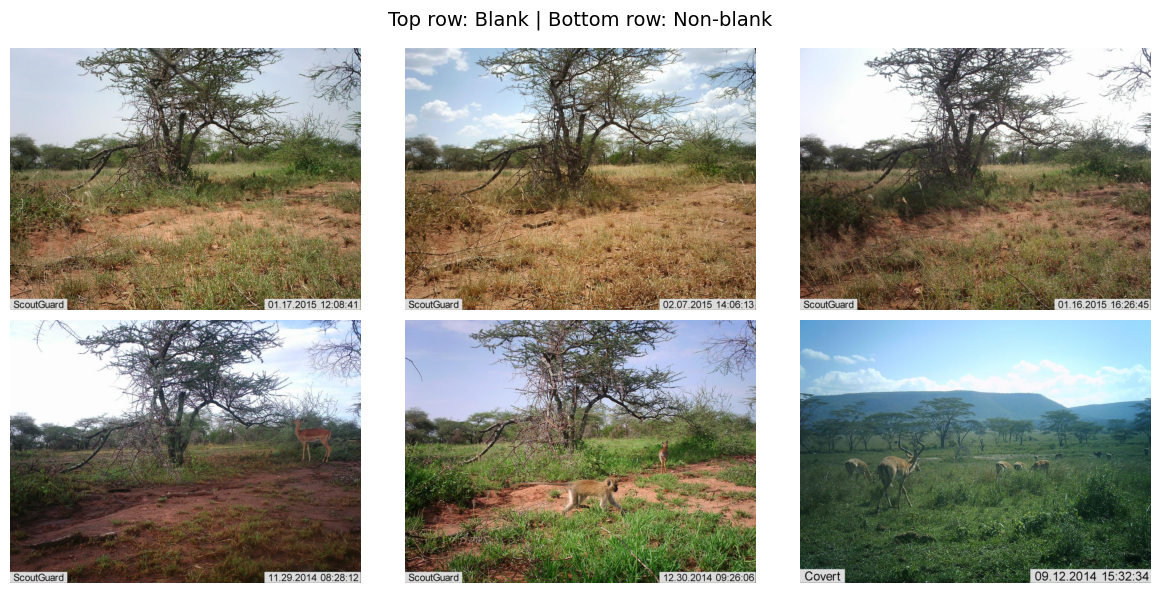

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Path to our folders
train_blank = '/kaggle/input/datasets/sylwiamielnicka/serengeti2/train/blank'
train_nonblank = '/kaggle/input/datasets/sylwiamielnicka/serengeti2/train/non_blank'

# Pick 3 images from each
blank_imgs = os.listdir(train_blank)[:3]
nonblank_imgs = os.listdir(train_nonblank)[:3]

# Display them
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle('Top row: Blank | Bottom row: Non-blank', fontsize=14)

for i, img_name in enumerate(blank_imgs):
    img = mpimg.imread(os.path.join(train_blank, img_name))
    axes[0, i].imshow(img)
    axes[0, i].axis('off')

for i, img_name in enumerate(nonblank_imgs):
    img = mpimg.imread(os.path.join(train_nonblank, img_name))
    axes[1, i].imshow(img)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Define transforms — resizing and normalizing images for the model
# ResNet expects 224x224 images, and specific mean/std values
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Load train and test datasets from folders
train_dataset = datasets.ImageFolder(
    '/kaggle/input/datasets/sylwiamielnicka/serengeti2/train', 
    transform=transform
)
test_dataset = datasets.ImageFolder(
    '/kaggle/input/datasets/sylwiamielnicka/serengeti2/test', 
    transform=transform
)

# DataLoader feeds images to the model in batches
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check what classes were detected
print(f"Classes: {train_dataset.classes}")
print(f"Total train images: {len(train_dataset)}")
print(f"Total test images: {len(test_dataset)}")

Classes: ['blank', 'non_blank']
Total train images: 2835
Total test images: 564


In [6]:
import torch.nn as nn

# Load ResNet18 pretrained on ImageNet (1.2 million images, 1000 classes)
model = models.resnet18(pretrained=True)

# Freeze all layers — we don't want to change what it already learned
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer — originally 1000 classes, we only need 2
model.fc = nn.Linear(model.fc.in_features, 2)

# Move model to GPU
model = model.to(device)

print("Model ready!")
print(f"Final layer: {model.fc}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s] 


Model ready!
Final layer: Linear(in_features=512, out_features=2, bias=True)


In [7]:
import torch.optim as optim

# Loss function — measures how wrong the model is
criterion = nn.CrossEntropyLoss()

# Optimizer — adjusts the model to reduce the loss (this is SGD's cousin!)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [8]:
# Train for 5 epochs (5 full passes through the training data)
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass — model makes predictions
        outputs = model(images)

        # Calculate loss — how wrong was it?
        loss = criterion(outputs, labels)

        # Backward pass — figure out how to improve
        loss.backward()

        # Update the weights
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss/len(train_loader):.4f} | Accuracy: {accuracy:.2f}%")

print("\nTraining complete!")

Epoch 1/5 | Loss: 0.4167 | Accuracy: 81.73%
Epoch 2/5 | Loss: 0.3005 | Accuracy: 88.25%
Epoch 3/5 | Loss: 0.2784 | Accuracy: 89.07%
Epoch 4/5 | Loss: 0.2729 | Accuracy: 89.03%
Epoch 5/5 | Loss: 0.2500 | Accuracy: 90.62%

Training complete!


In [9]:
model.eval()  # Switch to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # Don't calculate gradients during testing
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 83.69%


In [10]:
torch.save(model.state_dict(), 'wildlife_detector.pth')
print("Model saved!")

Model saved!


In [11]:
# New transform with augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),        # randomly flip image left-right
    transforms.RandomRotation(10),            # randomly rotate up to 10 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # vary lighting
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Test transform stays the same — no augmentation on test data
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

print("Augmented transforms ready!")

Augmented transforms ready!


In [12]:
# Reload datasets with new transforms
train_dataset2 = datasets.ImageFolder(
    '/kaggle/input/datasets/sylwiamielnicka/serengeti2/train', 
    transform=train_transform
)
test_dataset2 = datasets.ImageFolder(
    '/kaggle/input/datasets/sylwiamielnicka/serengeti2/test', 
    transform=test_transform
)

train_loader2 = DataLoader(train_dataset2, batch_size=32, shuffle=True)
test_loader2 = DataLoader(test_dataset2, batch_size=32, shuffle=False)

print(f"Train size: {len(train_dataset2)}")
print(f"Test size: {len(test_dataset2)}")

Train size: 2835
Test size: 564


In [13]:
# Fresh model
model2 = models.resnet18(weights='ResNet18_Weights.IMAGENET1K_V1')

for param in model2.parameters():
    param.requires_grad = False

model2.fc = nn.Linear(model2.fc.in_features, 2)
model2 = model2.to(device)

# Fresh optimizer
optimizer2 = optim.Adam(model2.fc.parameters(), lr=0.001)

# Train
num_epochs = 5

for epoch in range(num_epochs):
    model2.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader2:
        images, labels = images.to(device), labels.to(device)
        optimizer2.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer2.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{5} | Loss: {running_loss/len(train_loader2):.4f} | Accuracy: {accuracy:.2f}%")

print("\nTraining complete!")

Epoch 1/5 | Loss: 0.4741 | Accuracy: 76.86%
Epoch 2/5 | Loss: 0.3665 | Accuracy: 84.13%
Epoch 3/5 | Loss: 0.3323 | Accuracy: 85.57%
Epoch 4/5 | Loss: 0.3123 | Accuracy: 86.74%
Epoch 5/5 | Loss: 0.3084 | Accuracy: 86.14%

Training complete!


In [14]:
model2.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader2:
        images, labels = images.to(device), labels.to(device)
        outputs = model2(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_accuracy2 = 100 * correct / total
print(f"Model 1 Test Accuracy (no augmentation): 83.69%")
print(f"Model 2 Test Accuracy (with augmentation): {test_accuracy2:.2f}%")
print(f"Improvement: {test_accuracy2 - 83.69:.2f}%")

Model 1 Test Accuracy (no augmentation): 83.69%
Model 2 Test Accuracy (with augmentation): 85.11%
Improvement: 1.42%


In [15]:
torch.save(model2.state_dict(), 'wildlife_detector_augmented.pth')
print("Augmented model saved!")


Augmented model saved!


In [16]:
!pip install grad-cam -q
print("Done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.3 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Grad-CAM targets the last convolutional layer of ResNet
target_layers = [model2.layer4[-1]]

print("Grad-CAM ready!")

Grad-CAM ready!


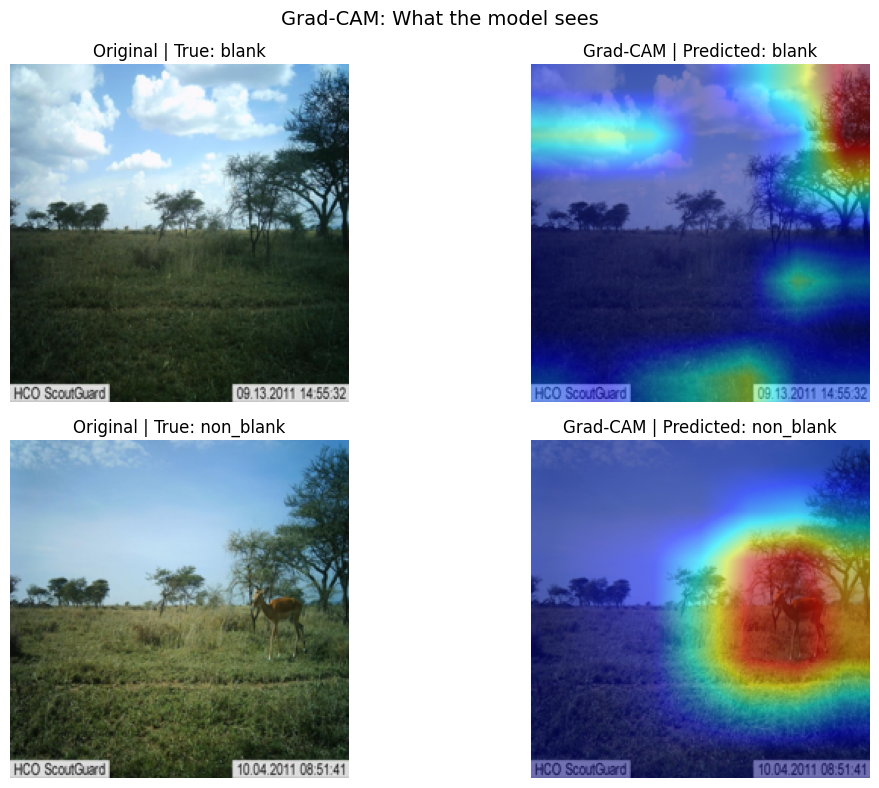

In [20]:
def run_gradcam(image_path, label):
    # Load original image for display
    orig_image = Image.open(image_path).convert('RGB')
    orig_image = orig_image.resize((224, 224))
    orig_array = np.array(orig_image) / 255.0

    # Preprocess for model
    input_tensor = test_transform(orig_image).unsqueeze(0).to(device)

    # Run Grad-CAM
    with GradCAM(model=model2, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor)[0]
        visualization = show_cam_on_image(orig_array.astype(np.float32), 
                                          grayscale_cam, use_rgb=True)

    # Get model prediction
    with torch.no_grad():
        output = model2(input_tensor)
        _, predicted = output.max(1)
        pred_label = train_dataset2.classes[predicted.item()]

    return visualization, pred_label, orig_array

# Pick one blank and one non_blank image
blank_path = os.path.join(train_blank, os.listdir(train_blank)[5])
nonblank_path = os.path.join(train_nonblank, os.listdir(train_nonblank)[5])

# Visualise both
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Grad-CAM: What the model sees', fontsize=14)

for row, (path, true_label) in enumerate([(blank_path, 'blank'), 
                                           (nonblank_path, 'non_blank')]):
    viz, pred, orig = run_gradcam(path, true_label)
    
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'Original | True: {true_label}')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(viz)
    axes[row, 1].set_title(f'Grad-CAM | Predicted: {pred}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

In [19]:
# Enable gradients for the last layer so Grad-CAM can work
for param in model2.layer4.parameters():
    param.requires_grad = True

print("Gradients enabled for layer4!")

Gradients enabled for layer4!


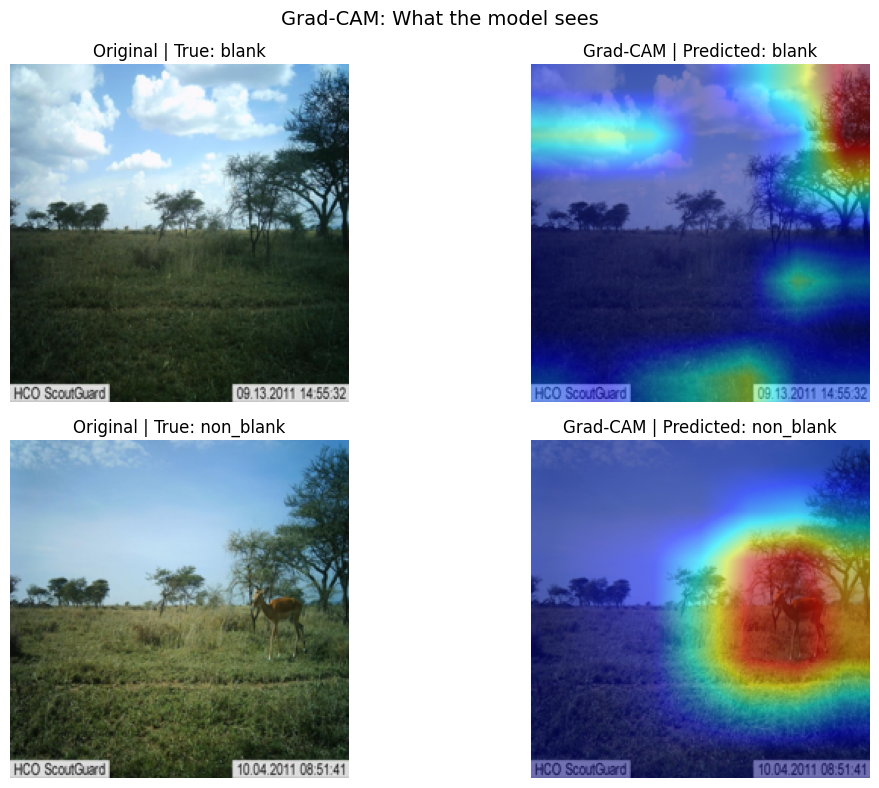

Saved!


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Grad-CAM: What the model sees', fontsize=14)

for row, (path, true_label) in enumerate([(blank_path, 'blank'), 
                                           (nonblank_path, 'non_blank')]):
    viz, pred, orig = run_gradcam(path, true_label)
    
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'Original | True: {true_label}')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(viz)
    axes[row, 1].set_title(f'Grad-CAM | Predicted: {pred}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig('gradcam_output.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved!")